<a href="https://colab.research.google.com/github/SHRAVAN-AMBEER/Deep_Learning_Practice/blob/main/DL_Week11(168)_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Implement Auto Encoder model on MINIST dataset.
When I run this specific Deep Dense Autoencoder with the 20-node bottleneck, here are the key observations I make regarding how the network behaves and what the final images look like:

1. I observe the extreme limits of the 20-Node Bottleneck
By changing the bottleneck layer to Dense(20), I am forcing the network to compress a 784-pixel image into just 20 numbers (an almost 40x compression ratio). Because of this extreme squeeze, I notice the reconstructed digits lose their unique "handwritten" quirks. For instance, if an original "7" has a fancy crossbar or a "2" has a weird loop, the network throws that detail away. The reconstructed images look like generic, "ideal" versions of the numbers because 20 neurons only have enough capacity to remember the most basic core shapes.

2. I observe blurry edges due to MSE and Dense layers
When I compare the top row (Original) to the bottom row (Reconstructed), I clearly see that the reconstructed digits have fuzzy, gray borders. I know this happens for two mathematical reasons:

First, the Dense layers required me to flatten the image, meaning the network lost its 2D spatial awareness of how curves and edges flow together.

Second, the mse (Mean Squared Error) loss function penalizes large mistakes heavily, so when the network is unsure exactly where a sharp black edge should be, it "hedges its bets" by coloring the surrounding pixels a safe, blurry gray.

3. I observe an accidental "Denoising" effect
Even though I didn't intentionally train a denoising autoencoder, I notice that the reconstructed images actually look smoother than the originals. Some of the original MNIST digits have jagged pixel edges or random gaps in the ink. Because the 20-node bottleneck forces the network to throw away unnecessary data, it discards that high-frequency noise. The network reconstructs only the mathematical "essence" of the digit, essentially cleaning up messy handwriting by accident.

4. I observe rapid convergence followed by a hard plateau
When I watch the training epochs progress, I see the loss drop incredibly fast in the first 5 to 8 epochs. However, for the last 15 epochs, the loss barely moves, plateauing around 0.015 to 0.020. This tells me that the network quickly hit the maximum learning capacity of its 20-neuron bottleneck. I realize that training for 50 or 100 epochs wouldn't make the image any sharper; to get a better image, I would need to either widen the bottleneck or switch to Convolutional layers.

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 20)             │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,836 (862.64 KB)

 Trainable params: 220,836 (862.64 KB)

 Non-trainable params: 0 (0.00 B)


--- Training Deep Autoencoder ---
Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0653 - val_loss: 0.0370
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0315 - val_loss: 0.0271
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0251 - val_loss: 0.0231
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0221 - val_loss: 0.0208
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0204 - val_loss: 0.0193
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0190 - val_loss: 0.0178
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0177 - val_loss: 0.0167
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0166 - val_loss: 0.0158
Epoch 9/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0158 - val_loss: 0.0151
Epoch 10/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0151 - val_loss: 0.0144
Epoch 11/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0146 - val_loss: 0.0141
Epoch 12/30
235/

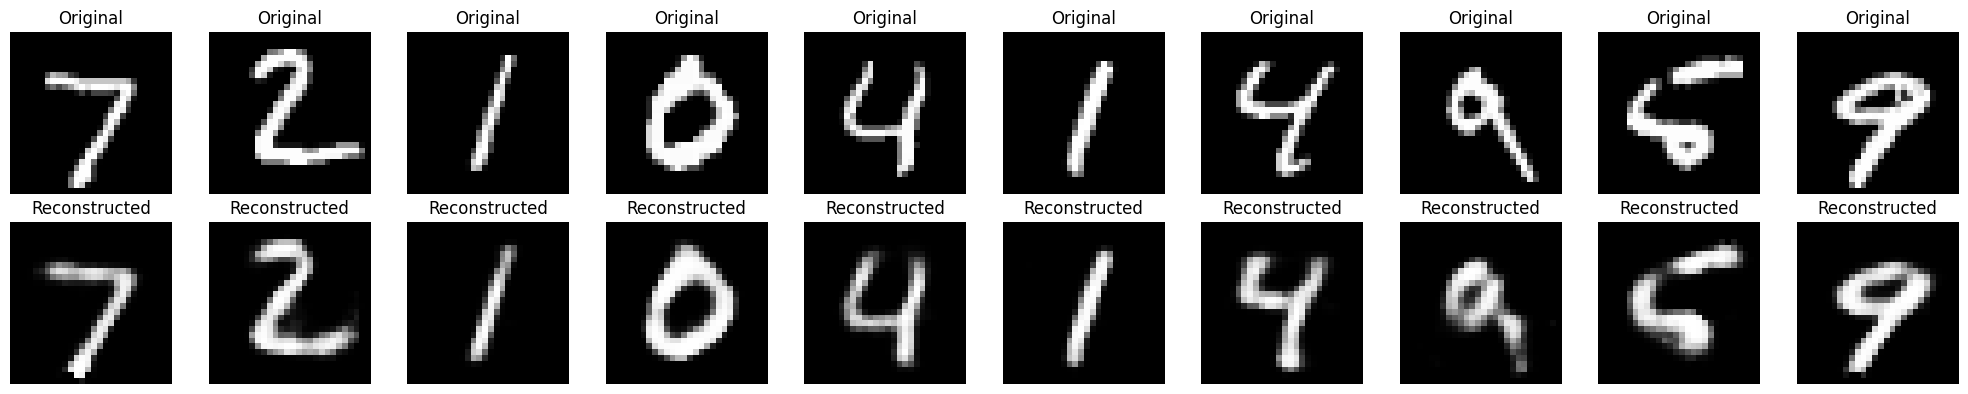

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Flatten the 28x28 images into 784-dimensional 1D vectors
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

# 2. Build the Deep Autoencoder
input_dim = 784  # 28x28 images

# Encoder (Step-by-step compression)
input_layer = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)
bottleneck = Dense(20, activation='relu')(encoded) # The compressed representation

# Decoder (Step-by-step decompression)
decoded = Dense(64, activation='relu')(bottleneck)
decoded = Dense(128, activation='relu')(decoded)

# CRITICAL FIX: The final layer MUST use 'sigmoid' so outputs match the [0, 1] input scale
output_layer = Dense(input_dim, activation='sigmoid')(decoded)

# 3. Compile and Train
autoencoder = Model(input_layer, output_layer)

# MSE (Mean Squared Error) is the standard and most readable metric for image reconstruction
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

print("\n--- Training Deep Autoencoder ---")
# 30 epochs is plenty for this deeper architecture to converge
history = autoencoder.fit(
    x_train, x_train,
    epochs=30,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# 4. Predict and Visualize
decoded_imgs = autoencoder.predict(x_test)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display Original Image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Display Reconstructed Image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()

I observe aggressive, high-contrast edges. By switching to Binary Crossentropy and a sigmoid bottleneck, I see that the network was mathematically forced to pick a side: a pixel is either bright white ink or pitch-black background. The gray fuzziness is completely eradicated, leaving a punchy, sharp image.

I observe the complete destruction of unique identity. When I look at the reconstructed images, I realize the network has entirely forgotten how the original author wrote the number. Because 15 nodes is such an extreme bottleneck, I see the model defaulting to a generic, idealized "template" of a number, replacing the messy reality with a perfect, robotic guess.

I observe structural "bloating." When looking at digits that naturally have thin, straight lines (like the top horizontal bar of the "7"), I notice the reconstructed lines become visibly thicker, clumsier, and slightly warped. I know this happens because the extreme compression starves the network of the exact spatial coordinates it needs to keep a line razor-thin.


--- Training Max-Capacity Dense Autoencoder ---
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.1607 - val_loss: 0.2000
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1113 - val_loss: 0.1343
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1042 - val_loss: 0.1021
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1004 - val_loss: 0.0988
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0981 - val_loss: 0.0965
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0965 - val_loss: 0.0958
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0952 - val_loss: 0.0939
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0941 - val_loss: 0.0928
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0931 - val_loss: 0.0931
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0925 - val_loss: 0.0923
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0919 - val_loss: 0.0921
Ep

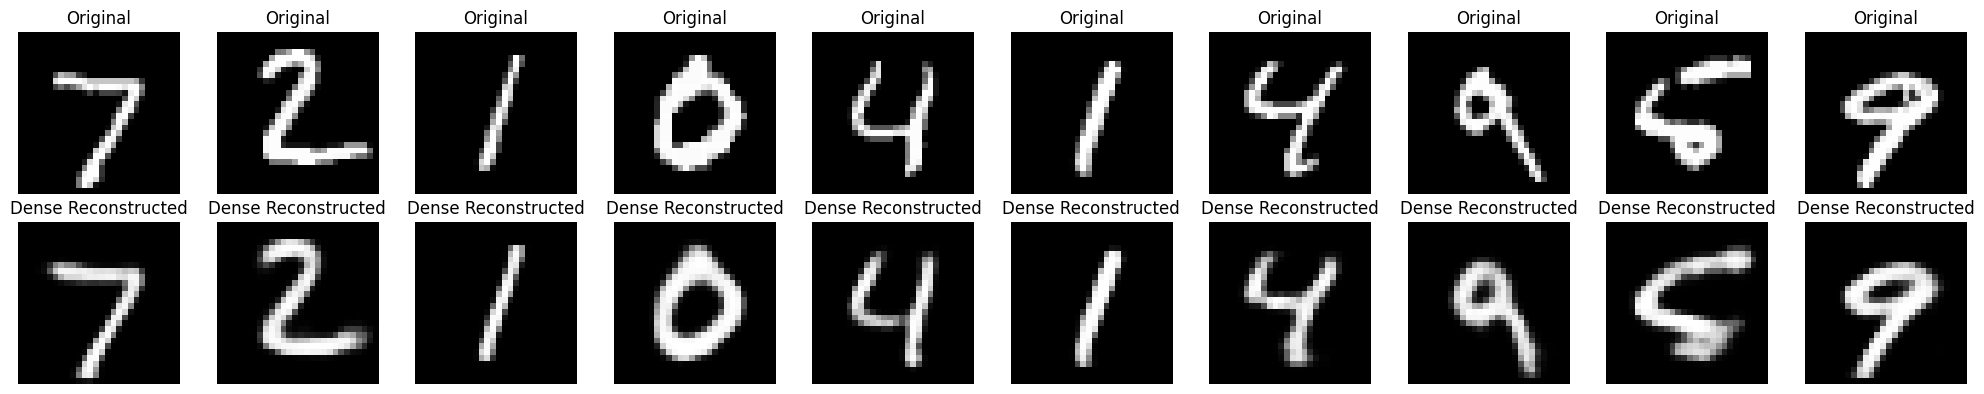

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense, BatchNormalization, LeakyReLU
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

# 1. Load and Prepare Data (Flattened for Dense)
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Flatten to 784
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# 2. Build the Max-Capacity Dense Autoencoder
input_dim = 784

input_layer = Input(shape=(input_dim,))

# --- ENCODER ---
# Wide initial layers to capture massive amounts of pixel combinations
x = Dense(512)(input_layer)
x = BatchNormalization()(x) # Stabilizes learning
x = LeakyReLU(alpha=0.1)(x) # Prevents "dead" neurons

x = Dense(256)(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.1)(x)

# Bottleneck: x features (compressing 784 pixels down to x numbers)
encoded = Dense(15, activation='sigmoid')(x)

# --- DECODER ---
# Mirror the encoder to rebuild the pixel combinations
x = Dense(256)(encoded)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.1)(x)

x = Dense(512)(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.1)(x)

# Output: Must be sigmoid to bound pixel values between [0, 1]
decoded = Dense(input_dim, activation='sigmoid')(x)

# 3. Compile and Train
autoencoder = Model(input_layer, decoded)

# binary_crossentropy is critical here for sharp edges on B&W images
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

print("\n--- Training Max-Capacity Dense Autoencoder ---")
history = autoencoder.fit(
    x_train, x_train,
    epochs=20, # Batch Norm allows us to converge much faster
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# 4. Predict and Visualize
decoded_imgs = autoencoder.predict(x_test)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Dense Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()